In [2]:
import os
import pandas as pd

# points to CLAS folder 
data_path = "D:/Major Project/CLAS/"

In [3]:
blocks = pd.read_csv(data_path + "Block_details/Part1_Block_Details.csv")
print(blocks.shape)
print(blocks.head(20))
print(blocks.columns.tolist())

(37, 9)
    Block  Block Type    ECG File     EDA&PPG File  Length(s)  EDA Quality  \
0       1    Baseline   1_ecg.csv   1_gsr_ppg_.csv      60.02          2.0   
1      10     Neutral  10_ecg.csv  10_gsr_ppg_.csv      29.99          1.0   
2      11  Video clip  11_ecg.csv  11_gsr_ppg_.csv      60.02          2.0   
3      12  Video clip  12_ecg.csv  12_gsr_ppg_.csv      60.03          2.0   
4      13  Video clip  13_ecg.csv  13_gsr_ppg_.csv      60.01          2.0   
5      14  Video clip  14_ecg.csv  14_gsr_ppg_.csv      60.00          2.0   
6      15     Neutral  15_ecg.csv  15_gsr_ppg_.csv      30.01          1.0   
7      16  Video clip  16_ecg.csv  16_gsr_ppg_.csv      60.04          2.0   
8      17  Video clip  17_ecg.csv  17_gsr_ppg_.csv      60.92          2.0   
9      18  Video clip  18_ecg.csv  18_gsr_ppg_.csv      59.11          2.0   
10     19  Video clip  19_ecg.csv  19_gsr_ppg_.csv      60.05          1.0   
11      2   Math Test   2_ecg.csv   2_gsr_ppg_.csv     1

In [4]:
ecg = pd.read_csv(data_path + "Participants/Part1/by_block/1_ecg_.csv")
print(ecg.shape)
print(ecg.head())
print(ecg.columns.tolist())

(15366, 4)
   Timestamp  PythonTimestamp        ecg1       ecg2
0    5657982     1.551792e+09 -605.000072 -28.231723
1    5658110     1.551792e+09 -605.000072 -27.248561
2    5658238     1.551792e+09 -605.000072 -25.665347
3    5658366     1.551792e+09 -605.000072 -25.818966
4    5658494     1.551792e+09 -605.000072 -27.447184
['Timestamp', 'PythonTimestamp', 'ecg1', 'ecg2']


In [5]:
gsr = pd.read_csv(data_path + "Participants/Part1/by_block/1_gsr_ppg_.csv")
print(gsr.shape)
print(gsr.head())
print(gsr.columns.tolist())

(15366, 7)
   Timestamp  PythonTimestamp  accelx  accely  accelz          ppg         gsr
0    8103095     1.551792e+09    1959    2739    2392  1423.443223  399.006139
1    8103223     1.551792e+09    1955    2746    2392  1418.315018  398.540146
2    8103351     1.551792e+09    1956    2744    2393  1412.454212  398.540146
3    8103479     1.551792e+09    1956    2740    2393  1405.128205  398.773006
4    8103607     1.551792e+09    1954    2743    2390  1400.000000  399.239544
['Timestamp', 'PythonTimestamp', 'accelx', 'accely', 'accelz', 'ppg', 'gsr']


In [6]:
print(blocks['Block Type'].unique())
print(blocks['Block Type'].value_counts())

['Baseline' 'Neutral' 'Video clip' 'Math Test' 'Math Test Response'
 'Pictures' 'Stroop Test' 'Stroop Test Response' 'IQ Test'
 'IQ Test Response']
Block Type
Video clip              16
Neutral                 10
Pictures                 4
Baseline                 1
Math Test                1
Math Test Response       1
Stroop Test              1
Stroop Test Response     1
IQ Test                  1
IQ Test Response         1
Name: count, dtype: int64


In [7]:
print(blocks['ECG Quality'].unique())
print(blocks['EDA Quality'].unique())

[2.]
[2. 1.]


In [8]:
# Strip column name spaces
blocks.columns = blocks.columns.str.strip()

In [9]:
# Define your label mapping
label_map = {
    'Baseline'   : 'LOW',
    'Neutral'    : 'LOW',
    'Math Test'  : 'HIGH',
    'IQ Test'    : 'HIGH',
    'Stroop Test': 'MEDIUM'
    # everything else gets dropped
}

In [10]:
# Step 3 - filter only the block types we want
blocks_filtered = blocks[blocks['Block Type'].isin(label_map.keys())]

In [11]:
# Step 4 - assign labels
blocks_filtered = blocks_filtered.copy()
blocks_filtered['Label'] = blocks_filtered['Block Type'].map(label_map)

In [12]:
# Step 5 - filter poor quality
# keep only rows where BOTH ECG and EDA quality == 2.0
blocks_filtered = blocks_filtered[
    (blocks_filtered['ECG Quality'] == 2.0) & 
    (blocks_filtered['EDA Quality'] == 2.0)
]

In [13]:
print(blocks_filtered[['Block', 'Block Type', 'Label', 'ECG File', 'EDA&PPG File']].to_string())
print(blocks_filtered['Label'].value_counts())
print(blocks_filtered.columns)

    Block Block Type Label    ECG File     EDA&PPG File
0       1   Baseline   LOW   1_ecg.csv   1_gsr_ppg_.csv
11      2  Math Test  HIGH   2_ecg.csv   2_gsr_ppg_.csv
23     30    Neutral   LOW  30_ecg.csv  30_gsr_ppg_.csv
25     32    Neutral   LOW  32_ecg.csv  32_gsr_ppg_.csv
27     34    Neutral   LOW  34_ecg.csv  34_gsr_ppg_.csv
29     36    Neutral   LOW  36_ecg.csv  36_gsr_ppg_.csv
34      7    Neutral   LOW   7_ecg.csv   7_gsr_ppg_.csv
35      8    IQ Test  HIGH   8_ecg.csv   8_gsr_ppg_.csv
Label
LOW     6
HIGH    2
Name: count, dtype: int64
Index(['Block', 'Block Type', 'ECG File', 'EDA&PPG File', 'Length(s)',
       'EDA Quality', 'ECG Quality', 'PPG Quality', 'Unnamed: 8', 'Label'],
      dtype='object')


In [14]:
# pick the first block to test with
test_block = blocks_filtered.iloc[0]
print(test_block)

Block                        1
Block Type            Baseline
ECG File             1_ecg.csv
EDA&PPG File    1_gsr_ppg_.csv
Length(s)                60.02
EDA Quality                2.0
ECG Quality                2.0
PPG Quality                2.0
Unnamed: 8                 NaN
Label                      LOW
Name: 0, dtype: object


In [15]:
# load its ECG signal
ecg_file = test_block['ECG File']
gsr_file = test_block['EDA&PPG File']

# add the correct subfolder path
participant_path = data_path + "Participants/Part1/by_block/"

In [16]:
# fix ECG filename mismatch
ecg_file = test_block['ECG File'].replace('1_ecg.csv', '1_ecg_.csv')
gsr_file = test_block['EDA&PPG File']  # this one might be fine already

In [17]:
ecg_signal = pd.read_csv(participant_path + ecg_file)
gsr_signal = pd.read_csv(participant_path + gsr_file)

print("ECG shape:", ecg_signal.shape)
print("GSR shape:", gsr_signal.shape)
print("\nECG head:\n", ecg_signal.head())
print("\nGSR head:\n", gsr_signal.head())

ECG shape: (15366, 4)
GSR shape: (15366, 7)

ECG head:
    Timestamp  PythonTimestamp        ecg1       ecg2
0    5657982     1.551792e+09 -605.000072 -28.231723
1    5658110     1.551792e+09 -605.000072 -27.248561
2    5658238     1.551792e+09 -605.000072 -25.665347
3    5658366     1.551792e+09 -605.000072 -25.818966
4    5658494     1.551792e+09 -605.000072 -27.447184

GSR head:
    Timestamp  PythonTimestamp  accelx  accely  accelz          ppg         gsr
0    8103095     1.551792e+09    1959    2739    2392  1423.443223  399.006139
1    8103223     1.551792e+09    1955    2746    2392  1418.315018  398.540146
2    8103351     1.551792e+09    1956    2744    2393  1412.454212  398.540146
3    8103479     1.551792e+09    1956    2740    2393  1405.128205  398.773006
4    8103607     1.551792e+09    1954    2743    2390  1400.000000  399.239544


In [18]:
pip install neurokit2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\MRUNMAYEE\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [ ]:
import neurokit2 as nk
import numpy as np

In [20]:
# we only need ecg2 column
ecg_raw = ecg_signal['ecg2'].values

# sampling rate of shimmer ECG is 128 Hz
sampling_rate = 128

# clean the signal and find R peaks
ecg_cleaned = nk.ecg_clean(ecg_raw, sampling_rate=128)
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=128)

# calculate HRV features
hrv_features = nk.hrv_time(peaks, sampling_rate=128)
hrv_freq = nk.hrv_frequency(peaks, sampling_rate=128)

print(hrv_features)
print(hrv_freq)

C:\Users\MRUNMAYEE\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\MRUNMAYEE\AppData\Local\Programs\Python\Python313\Lib\site-packages\neurokit2\hrv\hrv_time.py:165: RuntimeWarning: Mean of empty slice
  out["MeanNN"] = np.nanmean(rri)
C:\Users\MRUNMAYEE\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


IndexError: index 0 is out of bounds for axis 0 with size 0

In [21]:
# Check 1 - how many peaks detected
peak_indices = np.where(peaks['ECG_R_Peaks'] == 1)[0]
print("Number of R-peaks found:", len(peak_indices))
print("Signal length (seconds):", len(ecg_raw) / sampling_rate)

# Check 2 - actual sampling rate from timestamps
time_diff = ecg_signal['Timestamp'].diff().dropna()
print("Mean time between samples (ms):", time_diff.mean())
print("Actual sampling rate (Hz):", 1000 / time_diff.mean())

Number of R-peaks found: 1
Signal length (seconds): 120.046875
Mean time between samples (ms): 128.0
Actual sampling rate (Hz): 7.8125


In [22]:
# Step 1 - calculate real sampling rate from PythonTimestamp
time_diff = ecg_signal['PythonTimestamp'].diff().dropna()
actual_sr = 1 / time_diff.mean()
print("Actual sampling rate:", round(actual_sr), "Hz")


Actual sampling rate: 256 Hz


In [23]:
# Step 2 - use correct sampling rate
sampling_rate = round(actual_sr)  # should be 512

In [24]:
# Step 3 - redo peak detection with correct rate
ecg_raw = ecg_signal['ecg2'].values
ecg_cleaned = nk.ecg_clean(ecg_raw, sampling_rate=sampling_rate)
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)

In [25]:
# Step 4 - check peaks now
peak_indices = np.where(peaks['ECG_R_Peaks'] == 1)[0]
print("Number of R-peaks found:", len(peak_indices))
print("Expected peaks (~60-100 bpm for 120 seconds):", "120-200 peaks")

Number of R-peaks found: 72
Expected peaks (~60-100 bpm for 120 seconds): 120-200 peaks


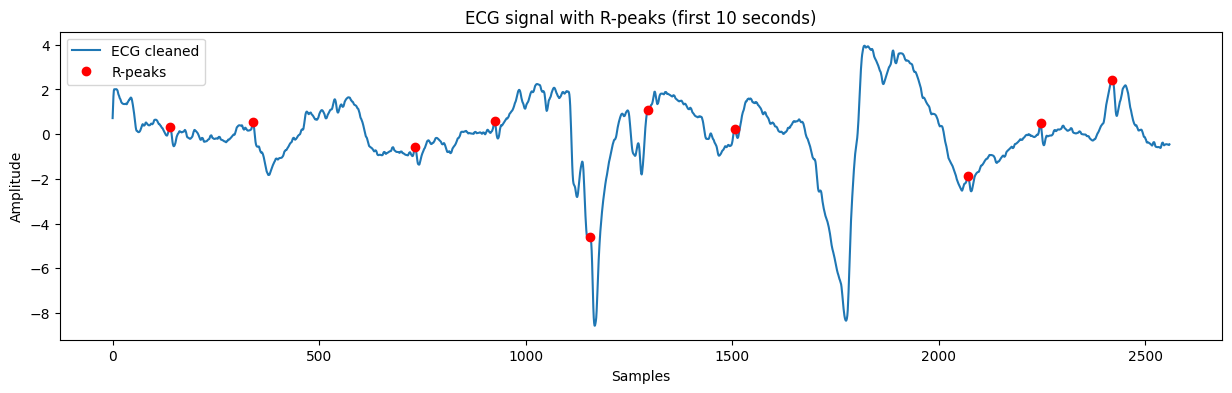

In [26]:
import matplotlib.pyplot as plt

# plot first 10 seconds only to see clearly
samples_10sec = 256 * 10

plt.figure(figsize=(15, 4))
plt.plot(ecg_cleaned[:samples_10sec], label='ECG cleaned')
plt.plot(peak_indices[peak_indices < samples_10sec], 
         ecg_cleaned[peak_indices[peak_indices < samples_10sec]], 
         'ro', label='R-peaks')
plt.legend()
plt.title('ECG signal with R-peaks (first 10 seconds)')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.show()

Number of R-peaks found: 70


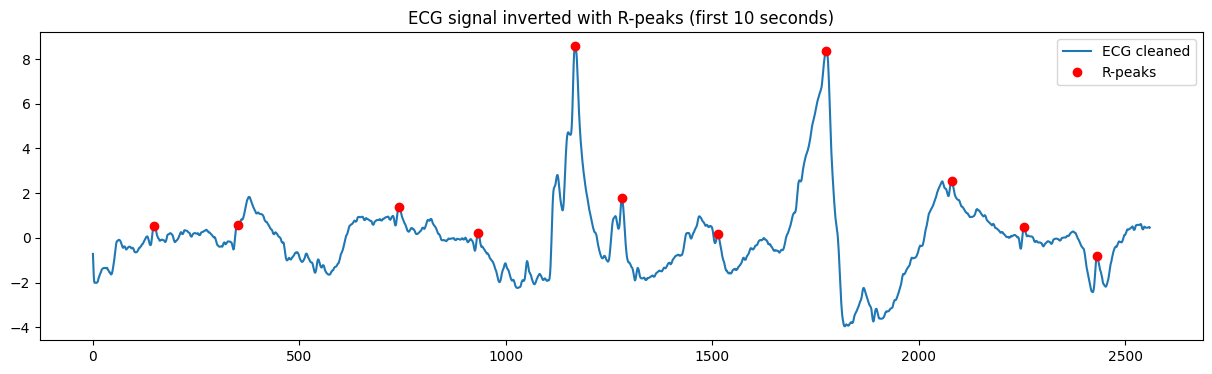

In [27]:
# seems like the signal is inverted so, reversing it
# invert the signal
ecg_raw = ecg_signal['ecg2'].values * -1

# redo everything with inverted signal
ecg_cleaned = nk.ecg_clean(ecg_raw, sampling_rate=256)
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=256)

peak_indices = np.where(peaks['ECG_R_Peaks'] == 1)[0]
print("Number of R-peaks found:", len(peak_indices))

# plot again
samples_10sec = 256 * 10
plt.figure(figsize=(15, 4))
plt.plot(ecg_cleaned[:samples_10sec], label='ECG cleaned')
plt.plot(peak_indices[peak_indices < samples_10sec], 
         ecg_cleaned[peak_indices[peak_indices < samples_10sec]], 
         'ro', label='R-peaks')
plt.legend()
plt.title('ECG signal inverted with R-peaks (first 10 seconds)')
plt.show()

Number of R-peaks found: 53


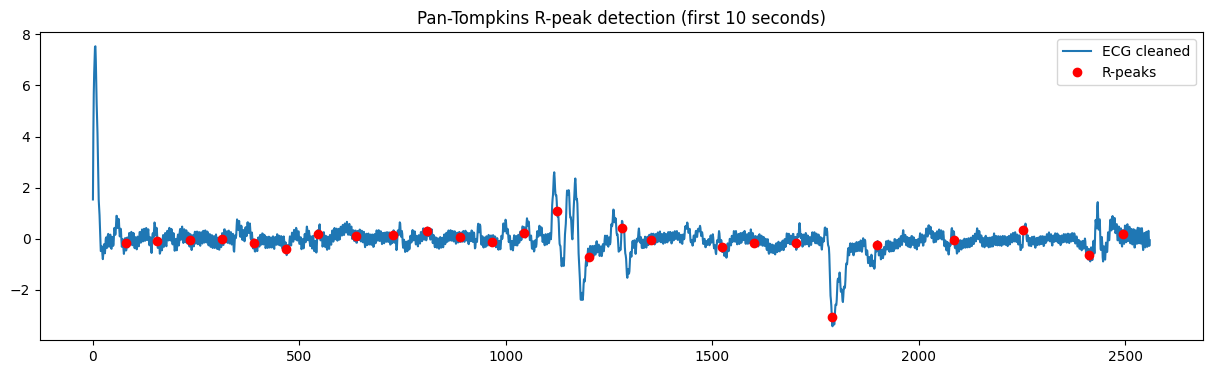

In [29]:
# try panginomtompkins method which is more robust
ecg_cleaned = nk.ecg_clean(ecg_raw, sampling_rate=256, method='pantompkins1985')
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=256, method='pantompkins1985')

peak_indices = np.where(peaks['ECG_R_Peaks'] == 1)[0]
print("Number of R-peaks found:", len(peak_indices))

# plot again
samples_10sec = 256 * 10
plt.figure(figsize=(15, 4))
plt.plot(ecg_cleaned[:samples_10sec], label='ECG cleaned')
plt.plot(peak_indices[peak_indices < samples_10sec], 
         ecg_cleaned[peak_indices[peak_indices < samples_10sec]], 
         'ro', label='R-peaks')
plt.legend()
plt.title('Pan-Tompkins R-peak detection (first 10 seconds)')
plt.show()

# no use of this signal

Block                        2
Block Type           Math Test
ECG File             2_ecg.csv
EDA&PPG File    2_gsr_ppg_.csv
Length(s)               168.92
EDA Quality                2.0
ECG Quality                2.0
PPG Quality                2.0
Unnamed: 8                 NaN
Label                     HIGH
Name: 11, dtype: object
Number of R-peaks found: 223
Signal length (seconds): 168.921875


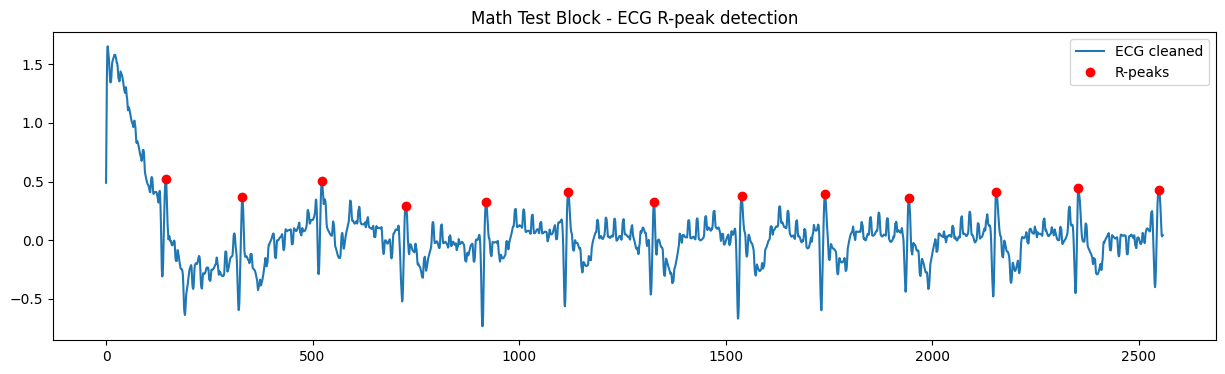

In [33]:
# find the math test block
math_block = blocks_filtered[blocks_filtered['Block Type'] == 'Math Test'].iloc[0]
print(math_block)

# load its signals
ecg_signal = pd.read_csv(participant_path + math_block['ECG File'].replace('_ecg.csv', '_ecg_mathtest.csv'))
gsr_signal = pd.read_csv(participant_path + math_block['EDA&PPG File'].replace('_gsr_ppg_.csv', '_gsr_ppg_mathtest.csv'))

# invert and clean
ecg_raw = ecg_signal['ecg2'].values * -1
ecg_cleaned = nk.ecg_clean(ecg_raw, sampling_rate=256)
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=256)

peak_indices = np.where(peaks['ECG_R_Peaks'] == 1)[0]
print("Number of R-peaks found:", len(peak_indices))
print("Signal length (seconds):", len(ecg_raw) / 256)

# plot first 10 seconds
samples_10sec = 256 * 10
plt.figure(figsize=(15, 4))
plt.plot(ecg_cleaned[:samples_10sec], label='ECG cleaned')
plt.plot(peak_indices[peak_indices < samples_10sec],
         ecg_cleaned[peak_indices[peak_indices < samples_10sec]],
         'ro', label='R-peaks')
plt.legend()
plt.title('Math Test Block - ECG R-peak detection')
plt.show()

In [34]:
# HRV time domain features
hrv_time = nk.hrv_time(peaks, sampling_rate=256)
print("HRV Time features:")
print(hrv_time)

# HRV frequency domain features
hrv_freq = nk.hrv_frequency(peaks, sampling_rate=256)
print("\nHRV Frequency features:")
print(hrv_freq)

HRV Time features:
   HRV_MeanNN   HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  756.492821  46.528804   21.580314   42.641257         NaN         NaN   

   HRV_SDANN5  HRV_SDNNI5  HRV_RMSSD   HRV_SDSD  ...  HRV_IQRNN  HRV_SDRMSSD  \
0         NaN         NaN  44.548953  44.648385  ...  57.617188     1.044442   

   HRV_Prc20NN  HRV_Prc80NN  HRV_pNN50  HRV_pNN20  HRV_MinNN  HRV_MaxNN  \
0       718.75    792.96875  16.666667  53.603604  636.71875   929.6875   

     HRV_HTI  HRV_TINN  
0  10.090909  195.3125  

[1 rows x 25 columns]

HRV Frequency features:
   HRV_ULF   HRV_VLF    HRV_LF    HRV_HF   HRV_VHF    HRV_TP  HRV_LFHF  \
0      NaN  0.002276  0.013847  0.009282  0.001251  0.026655  1.491839   

    HRV_LFn   HRV_HFn  HRV_LnHF  
0  0.519479  0.348214 -4.679716  


GSR basic stats:
Mean: 98.41634469263255
Std: 2.5381745559834386
Min: 93.1640903686088
Max: 109.52054794520548


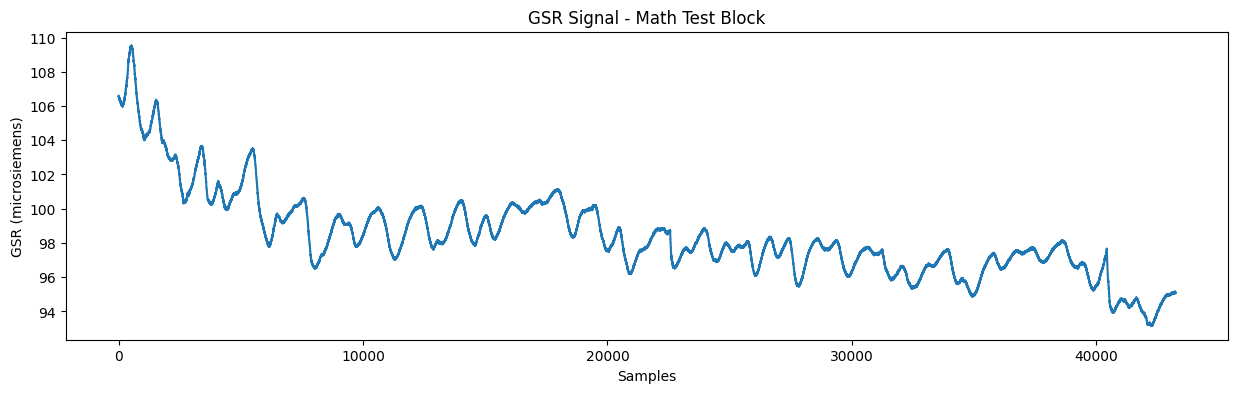

In [35]:
gsr_raw = gsr_signal['gsr'].values

print("GSR basic stats:")
print("Mean:", gsr_raw.mean())
print("Std:", gsr_raw.std())
print("Min:", gsr_raw.min())
print("Max:", gsr_raw.max())

# plot GSR signal
plt.figure(figsize=(15, 4))
plt.plot(gsr_raw)
plt.title('GSR Signal - Math Test Block')
plt.xlabel('Samples')
plt.ylabel('GSR (microsiemens)')
plt.show()

In [36]:
# GSR sampling rate is different from ECG
# calculate it same way we did for ECG
gsr_time_diff = gsr_signal['PythonTimestamp'].diff().dropna()
gsr_sr = round(1 / gsr_time_diff.mean())
print("GSR sampling rate:", gsr_sr, "Hz")

# extract simple statistical features
gsr_features = {
    'GSR_Mean'  : gsr_raw.mean(),
    'GSR_Std'   : gsr_raw.std(),
    'GSR_Min'   : gsr_raw.min(),
    'GSR_Max'   : gsr_raw.max(),
    'GSR_Slope' : np.polyfit(np.arange(len(gsr_raw)), gsr_raw, 1)[0],
    'GSR_Range' : gsr_raw.max() - gsr_raw.min()
}

print("\nGSR Features:")
for k, v in gsr_features.items():
    print(f"  {k}: {v:.4f}")

GSR sampling rate: 256 Hz

GSR Features:
  GSR_Mean: 98.4163
  GSR_Std: 2.5382
  GSR_Min: 93.1641
  GSR_Max: 109.5205
  GSR_Slope: -0.0002
  GSR_Range: 16.3565


In [37]:
# pick the specific HRV columns we want
ecg_features = {
    'HRV_MeanNN' : hrv_time['HRV_MeanNN'].values[0],
    'HRV_SDNN'   : hrv_time['HRV_SDNN'].values[0],
    'HRV_RMSSD'  : hrv_time['HRV_RMSSD'].values[0],
    'HRV_pNN50'  : hrv_time['HRV_pNN50'].values[0],
    'HRV_MinNN'  : hrv_time['HRV_MinNN'].values[0],
    'HRV_MaxNN'  : hrv_time['HRV_MaxNN'].values[0],
    'HRV_LF'     : hrv_freq['HRV_LF'].values[0],
    'HRV_HF'     : hrv_freq['HRV_HF'].values[0],
    'HRV_LFHF'   : hrv_freq['HRV_LFHF'].values[0],
    'HRV_LnHF'   : hrv_freq['HRV_LnHF'].values[0],
}

# combine ecg + gsr + label into one row
row = {**ecg_features, **gsr_features}
row['Label'] = math_block['Label']
row['Participant'] = 1
row['Block_Type'] = math_block['Block Type']

print(row)

{'HRV_MeanNN': np.float64(756.4928209459459), 'HRV_SDNN': np.float64(46.52880365370953), 'HRV_RMSSD': np.float64(44.548952829966794), 'HRV_pNN50': np.float64(16.666666666666664), 'HRV_MinNN': np.float64(636.71875), 'HRV_MaxNN': np.float64(929.6875), 'HRV_LF': np.float64(0.013846728649532885), 'HRV_HF': np.float64(0.009281652332013592), 'HRV_LFHF': np.float64(1.491838753944033), 'HRV_LnHF': np.float64(-4.679715695014879), 'GSR_Mean': np.float64(98.41634469263255), 'GSR_Std': np.float64(2.5381745559834386), 'GSR_Min': np.float64(93.1640903686088), 'GSR_Max': np.float64(109.52054794520548), 'GSR_Slope': np.float64(-0.00016303525405554433), 'GSR_Range': np.float64(16.356457576596682), 'Label': 'HIGH', 'Participant': 1, 'Block_Type': 'Math Test'}


In [ ]:
def extract_ecg_features(ecg_signal, sampling_rate=256):
    ecg_raw = ecg_signal['ecg2'].values * -1  # invert
    ecg_cleaned = nk.ecg_clean(ecg_raw, sampling_rate=sampling_rate)
    peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
    
    # check enough peaks found
    peak_indices = np.where(peaks['ECG_R_Peaks'] == 1)[0]
    if len(peak_indices) < 10:
        return None  # not enough peaks, skip this block
    
    hrv_time = nk.hrv_time(peaks, sampling_rate=sampling_rate)
    hrv_freq = nk.hrv_frequency(peaks, sampling_rate=sampling_rate)
    
    return {
        'HRV_MeanNN' : hrv_time['HRV_MeanNN'].values[0],
        'HRV_SDNN'   : hrv_time['HRV_SDNN'].values[0],
        'HRV_RMSSD'  : hrv_time['HRV_RMSSD'].values[0],
        'HRV_pNN50'  : hrv_time['HRV_pNN50'].values[0],
        'HRV_MinNN'  : hrv_time['HRV_MinNN'].values[0],
        'HRV_MaxNN'  : hrv_time['HRV_MaxNN'].values[0],
        'HRV_LF'     : hrv_freq['HRV_LF'].values[0],
        'HRV_HF'     : hrv_freq['HRV_HF'].values[0],
        'HRV_LFHF'   : hrv_freq['HRV_LFHF'].values[0],
        'HRV_LnHF'   : hrv_freq['HRV_LnHF'].values[0],
    }


In [ ]:
def extract_gsr_features(gsr_signal):
    gsr_raw = gsr_signal['gsr'].values
    return {
        'GSR_Mean'  : gsr_raw.mean(),
        'GSR_Std'   : gsr_raw.std(),
        'GSR_Min'   : gsr_raw.min(),
        'GSR_Max'   : gsr_raw.max(),
        'GSR_Slope' : np.polyfit(np.arange(len(gsr_raw)), gsr_raw, 1)[0],
        'GSR_Range' : gsr_raw.max() - gsr_raw.min()
    }